In [1]:
# Problema: Decidir cuándo y cuánta capacidad hospitalaria adicional activar ante una demanda futura incierta, sabiendo que preparar las camas toma varios días antes de poder usarlas.
# Las trayectorias son insumos; decidimos cuándo iniciar capacidad adicional.

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

data_dir = Path('../data')
submission_dir = Path('../submission')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})
display(['hospital.csv', 'daily_demand.csv', 'scenario_probabilities.csv'])

['hospital.csv', 'daily_demand.csv', 'scenario_probabilities.csv']

In [2]:
# Probabilidades de trayectorias completas, no de eventos diarios independientes.
hospital = pd.read_csv(data_dir / 'hospital.csv')
demand = pd.read_csv(data_dir / 'daily_demand.csv')
probabilities = pd.read_csv(data_dir / 'scenario_probabilities.csv')
display(hospital, demand, probabilities)

,hospital_id,horizon_days,initial_beds,max_blocks,beds_per_block,lead_time_days,activation_burden_per_block,operating_burden_per_bed_day,shortage_penalty_per_bed_day
0,H001,21,100,2,20,4,20,1,10


,day,low,central,high
0,1,60,70,70
1,2,64,74,74
2,3,68,78,78
3,4,72,82,82
4,5,76,86,86
5,6,80,90,90
6,7,85,95,95
7,8,90,100,100
8,9,98,108,120
9,10,105,115,130


,scenario_id,probability
0,low,0.25
1,central,0.65
2,high,0.10


In [3]:
# Demanda: camas simultáneamente requeridas. Cargas y penalizaciones: puntos pedagógicos.
h = hospital.iloc[0]
initial = int(h.initial_beds)
block_size = int(h.beds_per_block)
lead = int(h.lead_time_days)
horizon = int(h.horizon_days)
scenarios = probabilities.scenario_id.tolist()
assert len(hospital) == 1 and demand.day.tolist() == list(range(1, horizon + 1))
assert not demand.isna().any().any() and demand[scenarios].ge(0).all().all()
assert probabilities.scenario_id.is_unique and probabilities.probability.ge(0).all()
assert np.isclose(probabilities.probability.sum(), 1)
assert (initial, block_size, lead, int(h.max_blocks)) == (100, 20, 4, 2)
display(hospital.T)

,0
hospital_id,H001
horizon_days,21
initial_beds,100
max_blocks,2
beds_per_block,20
lead_time_days,4
activation_burden_per_block,20
operating_burden_per_bed_day,1
shortage_penalty_per_bed_day,10


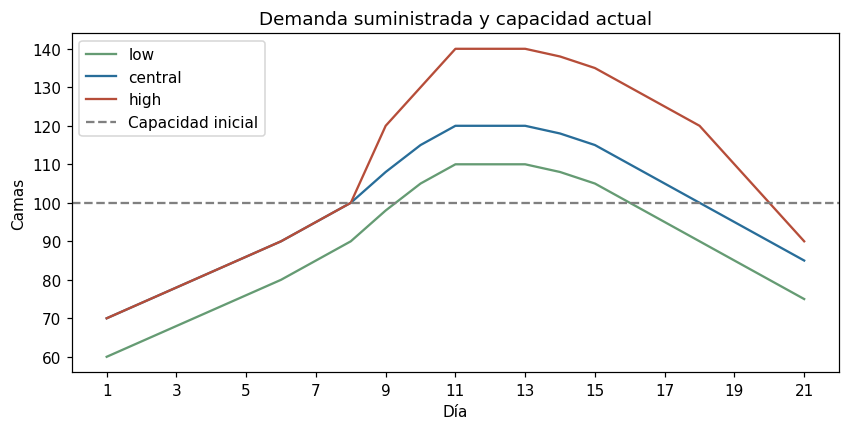

In [4]:
# Una necesidad futura puede exigir actuar antes de que aparezca.
colors = {'low': '#659b73', 'central': '#286d99', 'high': '#b64d39'}
fig, ax = plt.subplots(figsize=(9, 4))
for scenario in scenarios:
    ax.plot(demand.day, demand[scenario], label=scenario, color=colors[scenario])
ax.axhline(initial, color='gray', linestyle='--', label='Capacidad inicial')
ax.set(xlabel='Día', ylabel='Camas', title='Demanda suministrada y capacidad actual', xticks=range(1, 22, 2))
ax.legend()
plt.show()

In [5]:
# Alcanzar el límite no equivale todavía a superar la capacidad.
reaches_day = int(demand.loc[demand.central >= initial, 'day'].iloc[0])
exceeds_day = int(demand.loc[demand.central > initial, 'day'].iloc[0])
display(pd.Series({'alcanza_capacidad': reaches_day, 'supera_capacidad': exceeds_day, 'maximo_central': demand.central.max()}))

alcanza_capacidad      8
supera_capacidad       9
maximo_central       120
dtype: int64

In [6]:
# Reaccionar al límite: solicitar el bloque no lo vuelve disponible inmediatamente.
reactive_blocks = int(np.ceil((demand.central.max() - initial) / block_size))
reactive_start = reaches_day
reactive_available = reactive_start + lead
reactive_capacity = initial + np.where(demand.day >= reactive_available, reactive_blocks * block_size, 0)
display(pd.Series({'bloques': reactive_blocks, 'inicio': reactive_start, 'disponibilidad': reactive_available}))
display(pd.DataFrame({'day': demand.day, 'capacity': reactive_capacity}))

bloques            1
inicio             8
disponibilidad    12
dtype: int64

,day,capacity
0,1,100
1,2,100
2,3,100
3,4,100
4,5,100
5,6,100
6,7,100
7,8,100
8,9,100
9,10,100


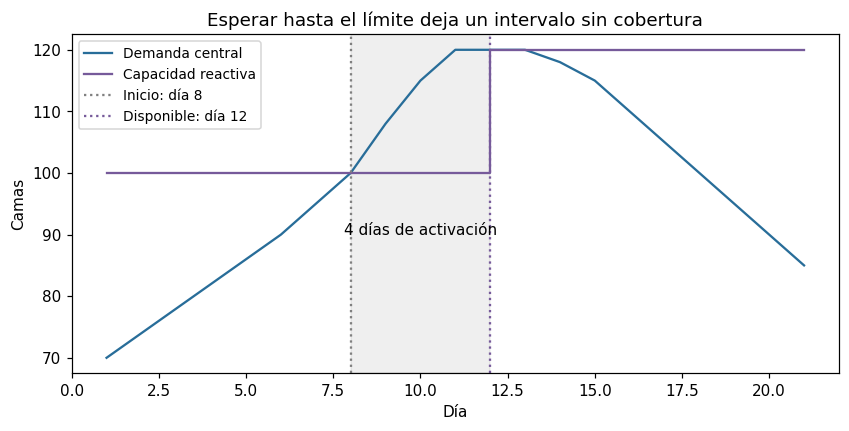

In [7]:
# La decisión y su efecto operativo ocurren en fechas diferentes.
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(demand.day, demand.central, color=colors['central'], label='Demanda central')
ax.step(demand.day, reactive_capacity, where='post', color='#765a9a', label='Capacidad reactiva')
ax.axvline(reactive_start, color='gray', linestyle=':', label=f'Inicio: día {reactive_start}')
ax.axvline(reactive_available, color='#765a9a', linestyle=':', label=f'Disponible: día {reactive_available}')
ax.axvspan(reactive_start, reactive_available, color='gray', alpha=0.12)
ax.annotate(f'{lead} días de activación', xy=(10, 90), ha='center')
ax.set(xlabel='Día', ylabel='Camas', title='Esperar hasta el límite deja un intervalo sin cobertura')
ax.legend(fontsize=9)
plt.show()

In [8]:
# Las diferencias diarias se suman como camas-día, no como pacientes distintos.
reactive_daily = demand[['day', 'central']].assign(capacity=reactive_capacity)
reactive_daily['unmet_beds'] = np.maximum(reactive_daily.central - reactive_daily.capacity, 0)
before_available = reactive_daily[reactive_daily.day < reactive_available]
central_reactive_shortage = before_available.unmet_beds.sum()
display(before_available[before_available.unmet_beds > 0])
print(f'Faltante central antes de disponibilidad: {central_reactive_shortage} camas-día')

,day,central,capacity,unmet_beds
8,9,108,100,8
9,10,115,100,15
10,11,120,100,20


Faltante central antes de disponibilidad: 43 camas-día


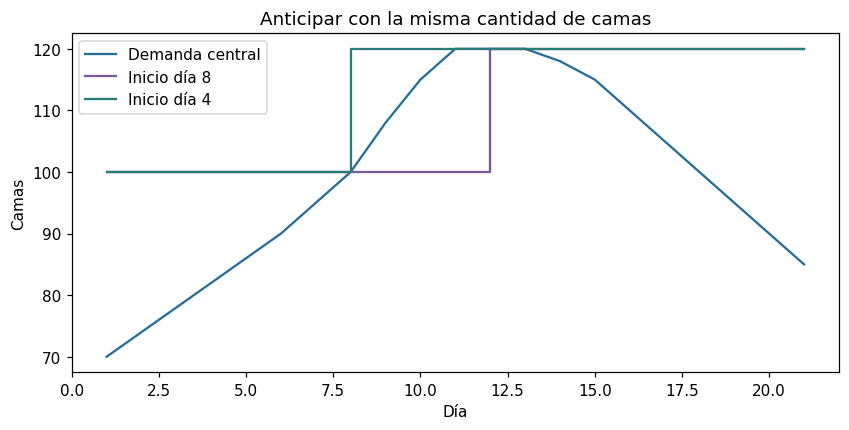

In [9]:
# Aislamos el efecto del plazo: mismo bloque, inicio cuatro días antes.
advance_start = reactive_start - lead
advance_available = advance_start + lead
advance_capacity = initial + np.where(demand.day >= advance_available, block_size, 0)
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(demand.day, demand.central, label='Demanda central', color=colors['central'])
ax.step(demand.day, reactive_capacity, where='post', label='Inicio día 8', color='#765a9a')
ax.step(demand.day, advance_capacity, where='post', label='Inicio día 4', color='#287d78')
ax.set(xlabel='Día', ylabel='Camas', title='Anticipar con la misma cantidad de camas')
ax.legend()
plt.show()

In [10]:
# El día 8 ninguna trayectoria supera 100: estar disponible el día 9 basta aquí.
later_start = exceeds_day - lead
later_capacity = initial + np.where(demand.day >= later_start + lead, block_size, 0)
start_comparison = pd.DataFrame({'day': demand.day, 'central': demand.central, 'start_4_capacity': advance_capacity, 'start_5_capacity': later_capacity})
display(start_comparison[start_comparison.day.between(7, 10)])
display(demand.loc[demand.day == 8])

,day,central,start_4_capacity,start_5_capacity
6,7,95,100,100
7,8,100,120,100
8,9,108,120,120
9,10,115,120,120


,day,low,central,high
7,8,90,100,100


In [11]:
# Un día operativo adicional puede añadir carga sin reducir faltantes.
early_rows = []
for start, capacity_line in [(advance_start, advance_capacity), (later_start, later_capacity)]:
    extra = capacity_line - initial
    burden = h.activation_burden_per_block + extra.sum() * h.operating_burden_per_bed_day
    unused = extra[:, None] - np.minimum(extra[:, None], np.maximum(demand[scenarios].to_numpy() - initial, 0))
    unmet = np.maximum(demand[scenarios].to_numpy() - capacity_line[:, None], 0)
    early_rows.append([start, start + lead, burden, unmet.sum(axis=0).tolist(), unused.sum(axis=0).tolist()])
display(pd.DataFrame(early_rows, columns=['start', 'available', 'burden', 'unmet_by_scenario', 'unused_by_scenario']))

,start,available,burden,unmet_by_scenario,unused_by_scenario
0,4,8,300,"[0, 0, 118]","[232, 149, 70]"
1,5,9,280,"[0, 0, 118]","[212, 129, 50]"


In [12]:
# Todos los planes se eligen con la misma información disponible hoy.
plan_rows = [('none', None, 0)]
for blocks in range(1, int(h.max_blocks) + 1):
    for start in range(3, 9):
        plan_rows.append((f'B{blocks}_D{start:02d}', start, blocks))
plans = pd.DataFrame(plan_rows, columns=['plan_id', 'activation_day', 'blocks'])
plans['activation_day'] = plans.activation_day.astype('Int64')
plans['available_day'] = plans.activation_day + lead
plans['added_beds'] = plans.blocks * block_size
display(plans)

,plan_id,activation_day,blocks,available_day,added_beds
0,none,<NA>,0,<NA>,0
1,B1_D03,3,1,7,20
2,B1_D04,4,1,8,20
3,B1_D05,5,1,9,20
4,B1_D06,6,1,10,20
5,B1_D07,7,1,11,20
6,B1_D08,8,1,12,20
7,B2_D03,3,2,7,40
8,B2_D04,4,2,8,40
9,B2_D05,5,2,9,40


In [13]:
# Los bloques de cada plan entran juntos al comienzo del día de disponibilidad.
capacity_daily = plans.merge(demand[['day']], how='cross')
operational = (capacity_daily.day >= capacity_daily.available_day).fillna(False)
capacity_daily['available_expansion_beds'] = np.where(operational, capacity_daily.added_beds, 0)
capacity_daily['initial_beds'] = initial
capacity_daily['total_capacity_beds'] = initial + capacity_daily.available_expansion_beds
capacity_daily['activation_started'] = capacity_daily.day.eq(capacity_daily.activation_day).fillna(False).astype(int)
display(capacity_daily.pivot(index='day', columns='plan_id', values='total_capacity_beds'))

plan_id,B1_D03,B1_D04,B1_D05,B1_D06,B1_D07,B1_D08,B2_D03,B2_D04,B2_D05,B2_D06,B2_D07,B2_D08,none
day,,,,,,,,,,,,,
1,100,100,100,100,100,100,100,100,100,100,100,100,100
2,100,100,100,100,100,100,100,100,100,100,100,100,100
3,100,100,100,100,100,100,100,100,100,100,100,100,100
4,100,100,100,100,100,100,100,100,100,100,100,100,100
5,100,100,100,100,100,100,100,100,100,100,100,100,100
6,100,100,100,100,100,100,100,100,100,100,100,100,100
7,120,100,100,100,100,100,140,100,100,100,100,100,100
8,120,120,100,100,100,100,140,140,100,100,100,100,100
9,120,120,120,100,100,100,140,140,140,100,100,100,100


In [14]:
# Evaluamos el mismo calendario bajo cada trayectoria, sin conocer cuál ocurrirá.
demand_long = demand.melt(id_vars='day', var_name='scenario_id', value_name='demand_beds')
daily = capacity_daily.merge(demand_long, on='day', validate='many_to_many')
daily['unmet_beds'] = np.maximum(daily.demand_beds - daily.total_capacity_beds, 0)
used_expansion = np.minimum(daily.available_expansion_beds, np.maximum(daily.demand_beds - initial, 0))
daily['unused_expansion_beds'] = daily.available_expansion_beds - used_expansion
display(daily.head())
print(f'{len(daily)} filas: plan × día × escenario')

,plan_id,activation_day,blocks,available_day,added_beds,day,available_expansion_beds,initial_beds,total_capacity_beds,activation_started,scenario_id,demand_beds,unmet_beds,unused_expansion_beds
0,none,<NA>,0,<NA>,0,1,0,100,100,0,low,60,0,0
1,none,<NA>,0,<NA>,0,1,0,100,100,0,central,70,0,0
2,none,<NA>,0,<NA>,0,1,0,100,100,0,high,70,0,0
3,none,<NA>,0,<NA>,0,2,0,100,100,0,low,64,0,0
4,none,<NA>,0,<NA>,0,2,0,100,100,0,central,74,0,0


819 filas: plan × día × escenario


In [15]:
# La ociosidad incluye solo expansión; su carga operativa no se penaliza dos veces.
burden = capacity_daily.groupby('plan_id').available_expansion_beds.sum() * h.operating_burden_per_bed_day
burden += plans.set_index('plan_id').blocks * h.activation_burden_per_block
burden.name = 'expansion_burden'
plan_scenario_results = daily.groupby(['plan_id', 'scenario_id'], as_index=False).agg(unmet_bed_days=('unmet_beds', 'sum'), unused_expansion_bed_days=('unused_expansion_beds', 'sum'))
plan_scenario_results = plan_scenario_results.merge(probabilities, on='scenario_id', validate='many_to_one').merge(burden, on='plan_id', validate='many_to_one')
plan_scenario_results['scenario_score'] = plan_scenario_results.expansion_burden + h.shortage_penalty_per_bed_day * plan_scenario_results.unmet_bed_days
display(plan_scenario_results)

,plan_id,scenario_id,unmet_bed_days,unused_expansion_bed_days,probability,expansion_burden,scenario_score
0,B1_D03,central,0,169,0.65,320,320
1,B1_D03,high,118,90,0.10,320,1500
2,B1_D03,low,0,252,0.25,320,320
3,B1_D04,central,0,149,0.65,300,300
4,B1_D04,high,118,70,0.10,300,1480
5,B1_D04,low,0,232,0.25,300,300
6,B1_D05,central,0,129,0.65,280,280
7,B1_D05,high,118,50,0.10,280,1460
8,B1_D05,low,0,212,0.25,280,280
9,B1_D06,central,8,117,0.65,260,340


In [16]:
# Los puntos permiten comparar planes; no son dinero ni daño clínico estimado.
weighted = plan_scenario_results[['unmet_bed_days', 'unused_expansion_bed_days', 'scenario_score']].mul(plan_scenario_results.probability, axis=0)
expected = weighted.groupby(plan_scenario_results.plan_id).sum().rename(columns={'unmet_bed_days': 'expected_unmet_bed_days', 'unused_expansion_bed_days': 'expected_unused_expansion_bed_days', 'scenario_score': 'score'})
evaluated_plans = plans.merge(burden, on='plan_id').merge(expected, on='plan_id')
display(evaluated_plans.sort_values(['score', 'plan_id']))

,plan_id,activation_day,blocks,available_day,added_beds,expansion_burden,expected_unmet_bed_days,expected_unused_expansion_bed_days,score
3,B1_D05,5,1,9,20,280,11.80,141.85,398.0
2,B1_D04,4,1,8,20,300,11.80,161.85,418.0
1,B1_D03,3,1,7,20,320,11.80,181.85,438.0
4,B1_D06,6,1,10,20,260,19.00,129.05,450.0
5,B1_D07,7,1,11,20,240,32.00,122.05,560.0
9,B2_D05,5,2,9,40,560,0.00,390.05,560.0
10,B2_D06,6,2,10,40,520,7.20,357.25,592.0
8,B2_D04,4,2,8,40,600,0.00,430.05,600.0
7,B2_D03,3,2,7,40,640,0.00,470.05,640.0
11,B2_D07,7,2,11,40,480,21.20,331.25,692.0


In [17]:
# Elegimos fecha y cantidad entre las 13 alternativas, conservando el riesgo visible.
best = evaluated_plans.sort_values(['score', 'plan_id']).iloc[0]
best_id = best.plan_id
evaluated_plans['is_recommended'] = evaluated_plans.plan_id.eq(best_id)
assert np.isclose(evaluated_plans.score, best.score).sum() == 1
display(best)

plan_id                               B1_D05
activation_day                             5
blocks                                     1
available_day                              9
added_beds                                20
expansion_burden                         280
expected_unmet_bed_days                 11.8
expected_unused_expansion_bed_days    141.85
score                                  398.0
Name: 3, dtype: object

In [18]:
# Una recomendación debe compararse con decisiones alternativas comprensibles.
key_ids = ['none', 'B1_D08', 'B1_D04', 'B1_D05', 'B1_D06', 'B2_D05']
key_labels = ['Sin ampliar', 'Reactivo D8', '1 bloque D4', 'Recomendado D5', '1 bloque D6', '2 bloques D5']
key_plans = evaluated_plans.set_index('plan_id').loc[key_ids].copy()
display(key_plans[['activation_day', 'available_day', 'blocks', 'expected_unmet_bed_days', 'expected_unused_expansion_bed_days', 'expansion_burden', 'score']])

,activation_day,available_day,blocks,expected_unmet_bed_days,expected_unused_expansion_bed_days,expansion_burden,score
plan_id,,,,,,,
none,<NA>,<NA>,0,129.95,0.00,0,1299.5
B1_D08,8,12,1,49.50,119.55,220,715.0
B1_D04,4,8,1,11.80,161.85,300,418.0
B1_D05,5,9,1,11.80,141.85,280,398.0
B1_D06,6,10,1,19.00,129.05,260,450.0
B2_D05,5,9,2,0.00,390.05,560,560.0


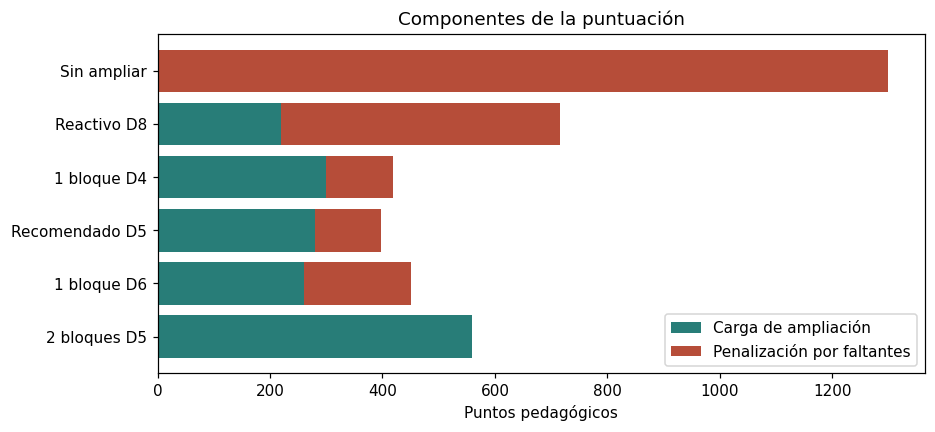

In [19]:
# Separamos la preparación operativa de la penalización por falta de capacidad.
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(key_labels, key_plans.expansion_burden, label='Carga de ampliación', color='#287d78')
ax.barh(key_labels, h.shortage_penalty_per_bed_day * key_plans.expected_unmet_bed_days, left=key_plans.expansion_burden, label='Penalización por faltantes', color='#b64d39')
ax.invert_yaxis()
ax.set(xlabel='Puntos pedagógicos', title='Componentes de la puntuación')
ax.legend()
plt.show()

In [20]:
# Retrasar del día 5 al 6 ahorra operación, pero pierde un día de cobertura.
timing = evaluated_plans.set_index('plan_id').loc[['B1_D04', 'B1_D05', 'B1_D06']]
display(timing[['expected_unmet_bed_days', 'expected_unused_expansion_bed_days', 'expansion_burden', 'score']])
change = timing.loc['B1_D06', ['expected_unmet_bed_days', 'expansion_burden', 'score']] - timing.loc['B1_D05', ['expected_unmet_bed_days', 'expansion_burden', 'score']]
display(change.rename('cambio_al_retrasar_un_dia'))

,expected_unmet_bed_days,expected_unused_expansion_bed_days,expansion_burden,score
plan_id,,,,
B1_D04,11.8,161.85,300,418.0
B1_D05,11.8,141.85,280,398.0
B1_D06,19.0,129.05,260,450.0


expected_unmet_bed_days     7.2
expansion_burden            -20
score                      52.0
Name: cambio_al_retrasar_un_dia, dtype: object

In [21]:
# El segundo bloque reduce riesgo, pero todas sus camas operativas generan carga.
size_comparison = evaluated_plans.set_index('plan_id').loc[['B1_D05', 'B2_D05']]
display(size_comparison[['blocks', 'expected_unmet_bed_days', 'expected_unused_expansion_bed_days', 'expansion_burden', 'score']])

,blocks,expected_unmet_bed_days,expected_unused_expansion_bed_days,expansion_burden,score
plan_id,,,,,
B1_D05,1,11.8,141.85,280,398.0
B2_D05,2,0.0,390.05,560,560.0


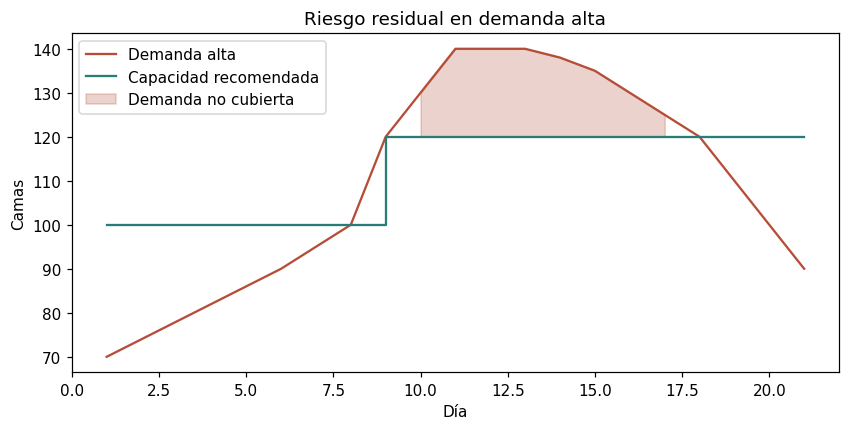

,unmet_bed_days,unused_expansion_bed_days
scenario_id,,
low,0,212
central,0,129
high,118,50


In [22]:
# Minimizar la puntuación esperada no garantiza suficiencia en el escenario alto.
residual = plan_scenario_results[plan_scenario_results.plan_id == best_id].set_index('scenario_id').loc[scenarios]
best_capacity = capacity_daily[capacity_daily.plan_id == best_id].sort_values('day')
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(demand.day, demand.high, color=colors['high'], label='Demanda alta')
ax.step(demand.day, best_capacity.total_capacity_beds, where='post', color='#287d78', label='Capacidad recomendada')
ax.fill_between(demand.day.to_numpy(), best_capacity.total_capacity_beds.to_numpy(), demand.high.to_numpy(), where=(demand.high.to_numpy() > best_capacity.total_capacity_beds.to_numpy()), color=colors['high'], alpha=0.25, label='Demanda no cubierta')
ax.set(xlabel='Día', ylabel='Camas', title='Riesgo residual en demanda alta')
ax.legend()
plt.show()
display(residual[['unmet_bed_days', 'unused_expansion_bed_days']])

In [23]:
# Exploración separada: aumenta la probabilidad de la trayectoria alta.
variant_probabilities = pd.Series({'low': 0.25, 'central': 0.45, 'high': 0.30})
variant_weights = plan_scenario_results.scenario_id.map(variant_probabilities)
variant_scores = (plan_scenario_results.scenario_score * variant_weights).groupby(plan_scenario_results.plan_id).sum()
display(variant_scores.sort_values())

plan_id
B2_D05     560.0
B2_D04     600.0
B2_D06     616.0
B1_D05     634.0
B2_D03     640.0
B1_D04     654.0
B1_D03     674.0
B1_D06     710.0
B2_D07     746.0
B1_D07     830.0
B2_D08     941.0
B1_D08     985.0
none      1693.5
dtype: float64

In [24]:
# Cambia la cantidad recomendada; los entregables seguirán usando el escenario base.
variant_best_id = variant_scores.idxmin()
display(pd.DataFrame({'base_score': evaluated_plans.set_index('plan_id').score, 'variant_score': variant_scores}).loc[['B1_D05', 'B2_D05']])
display(plans.set_index('plan_id').loc[variant_best_id])

,base_score,variant_score
plan_id,,
B1_D05,398.0,634.0
B2_D05,560.0,560.0


activation_day     5
blocks             2
available_day      9
added_beds        40
Name: B2_D05, dtype: Int64

In [25]:
# Conservamos alternativas, escenarios y detalle diario de la recomendación base.
evaluated_columns = ['plan_id', 'activation_day', 'available_day', 'blocks', 'added_beds', 'expansion_burden', 'expected_unmet_bed_days', 'expected_unused_expansion_bed_days', 'score', 'is_recommended']
scenario_columns = ['plan_id', 'scenario_id', 'probability', 'unmet_bed_days', 'unused_expansion_bed_days', 'expansion_burden', 'scenario_score']
daily_columns = ['plan_id', 'day', 'scenario_id', 'demand_beds', 'initial_beds', 'available_expansion_beds', 'total_capacity_beds', 'unmet_beds', 'unused_expansion_beds', 'activation_started']
evaluated_plans = evaluated_plans[evaluated_columns]
plan_scenario_results = plan_scenario_results[scenario_columns].sort_values(['plan_id', 'scenario_id'])
recommended_daily_plan = daily.loc[daily.plan_id == best_id, daily_columns].sort_values(['day', 'scenario_id'])
display(pd.Series({'planes': len(evaluated_plans), 'plan_escenario': len(plan_scenario_results), 'recomendacion_diaria': len(recommended_daily_plan)}))

planes                  13
plan_escenario          39
recomendacion_diaria    63
dtype: int64

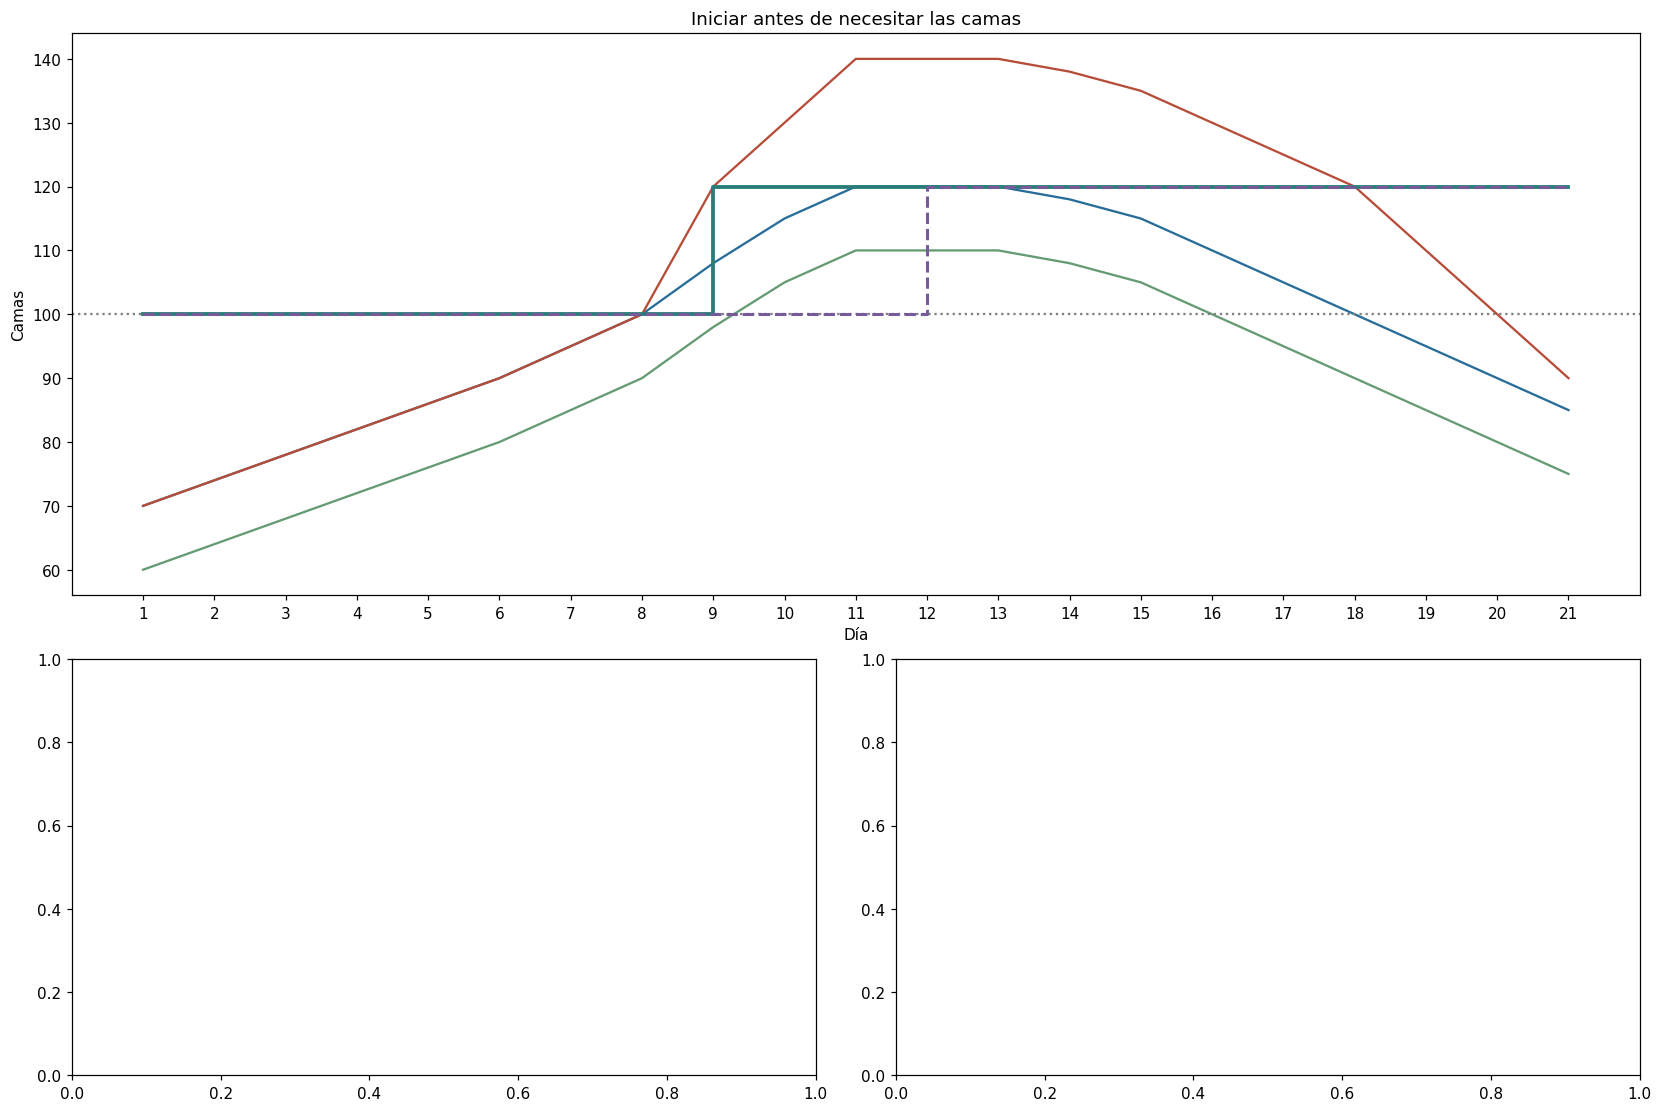

In [26]:
# La capacidad escalonada hace visible cuándo una decisión empieza a tener efecto.
planner_fig = plt.figure(figsize=(15, 10), layout='constrained')
grid = planner_fig.add_gridspec(2, 2, height_ratios=[1.35, 1])
trajectory_ax = planner_fig.add_subplot(grid[0, :])
scenario_ax = planner_fig.add_subplot(grid[1, 0])
comparison_ax = planner_fig.add_subplot(grid[1, 1])
for scenario in scenarios:
    trajectory_ax.plot(demand.day, demand[scenario], color=colors[scenario], label=f'Demanda {scenario}')
trajectory_ax.axhline(initial, color='gray', linestyle=':', label='Inicial: 100 camas')
trajectory_ax.step(demand.day, best_capacity.total_capacity_beds, where='post', color='#287d78', linewidth=2.5, label='Capacidad recomendada')
trajectory_ax.step(demand.day, reactive_capacity, where='post', color='#765a9a', linestyle='--', linewidth=2, label='Capacidad reactiva')
trajectory_ax.set(xlabel='Día', ylabel='Camas', xticks=range(1, 22), title='Iniciar antes de necesitar las camas')
plt.show()

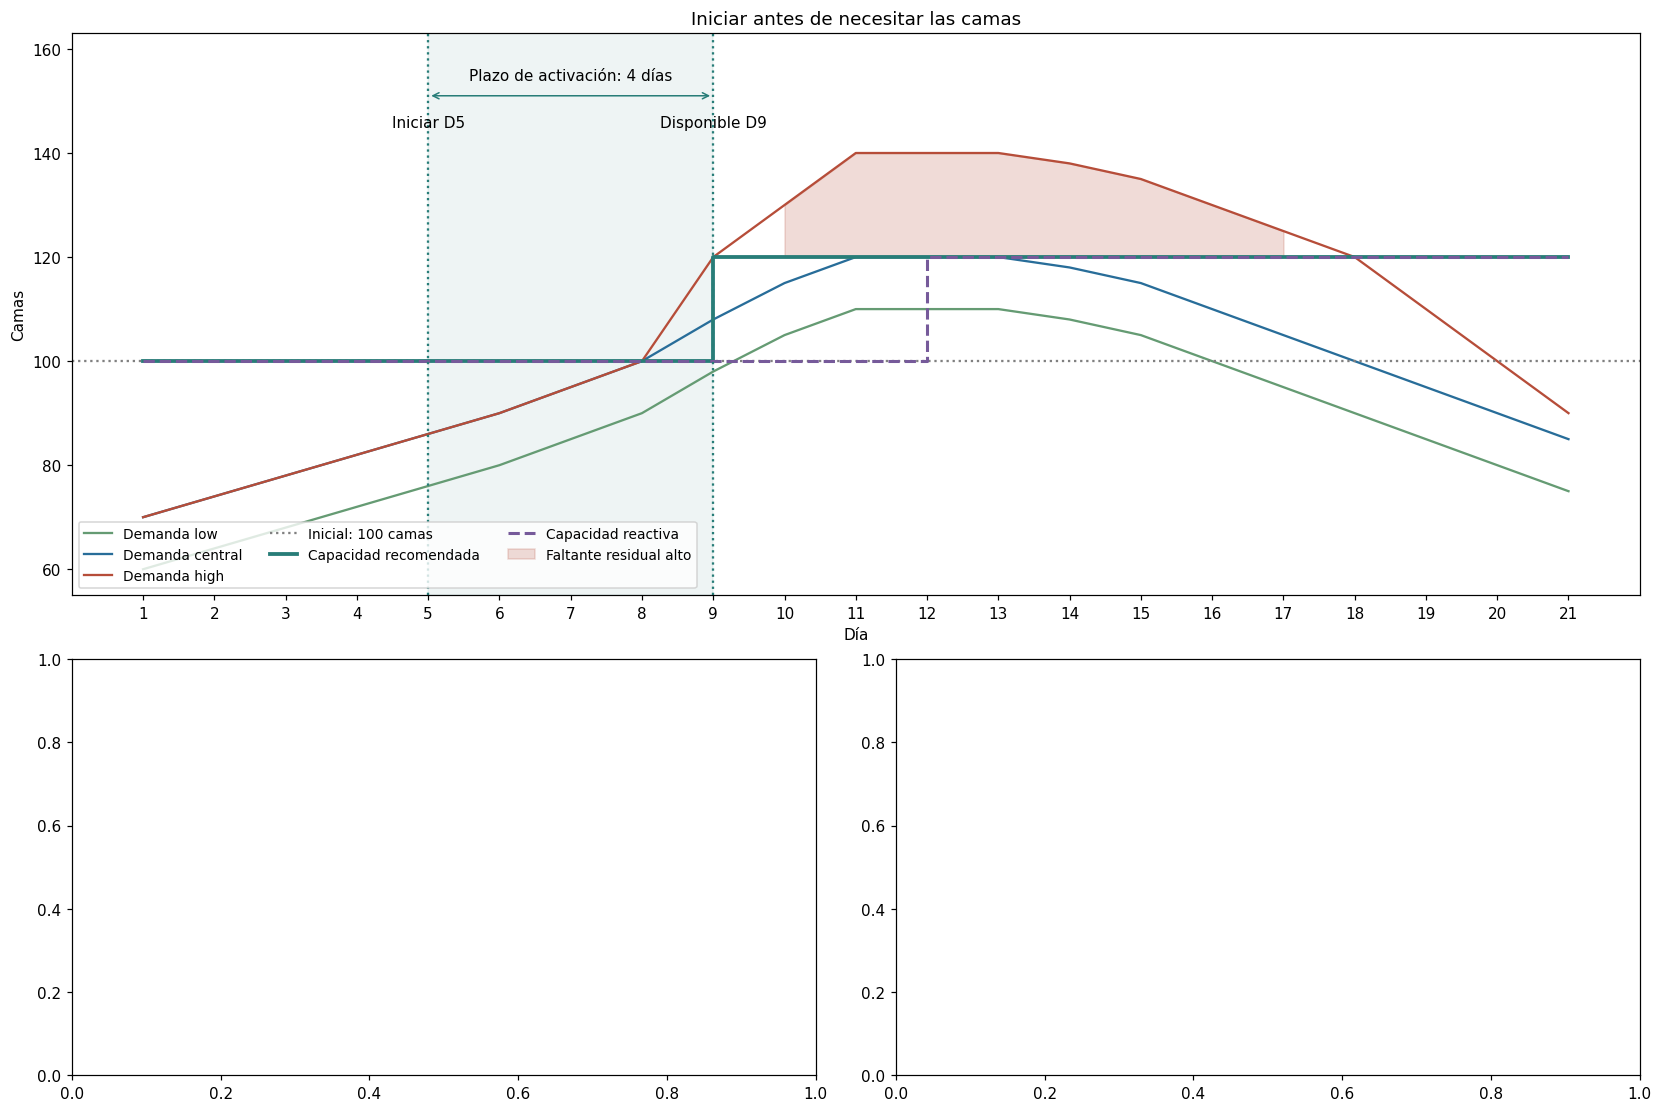

In [27]:
# Inicio día 5, disponibilidad día 9: el intervalo de preparación debe anticiparse.
start = int(best.activation_day)
available = int(best.available_day)
trajectory_ax.axvline(start, color='#287d78', linestyle=':')
trajectory_ax.axvline(available, color='#287d78', linestyle=':')
trajectory_ax.axvspan(start, available, color='#287d78', alpha=0.08)
trajectory_ax.annotate('', xy=(available, 151), xytext=(start, 151), arrowprops={'arrowstyle': '<->', 'color': '#287d78'})
trajectory_ax.text((start + available) / 2, 154, f'Plazo de activación: {lead} días', ha='center', fontsize=10)
trajectory_ax.text(start, 145, f'Iniciar D{start}', ha='center', fontsize=10)
trajectory_ax.text(available, 145, f'Disponible D{available}', ha='center', fontsize=10)
trajectory_ax.fill_between(demand.day.to_numpy(), best_capacity.total_capacity_beds.to_numpy(), demand.high.to_numpy(), where=(demand.high.to_numpy() > best_capacity.total_capacity_beds.to_numpy()), color=colors['high'], alpha=0.2, label='Faltante residual alto')
trajectory_ax.set_ylim(55, 163)
trajectory_ax.legend(loc='lower left', ncol=3, fontsize=9)
display(planner_fig)

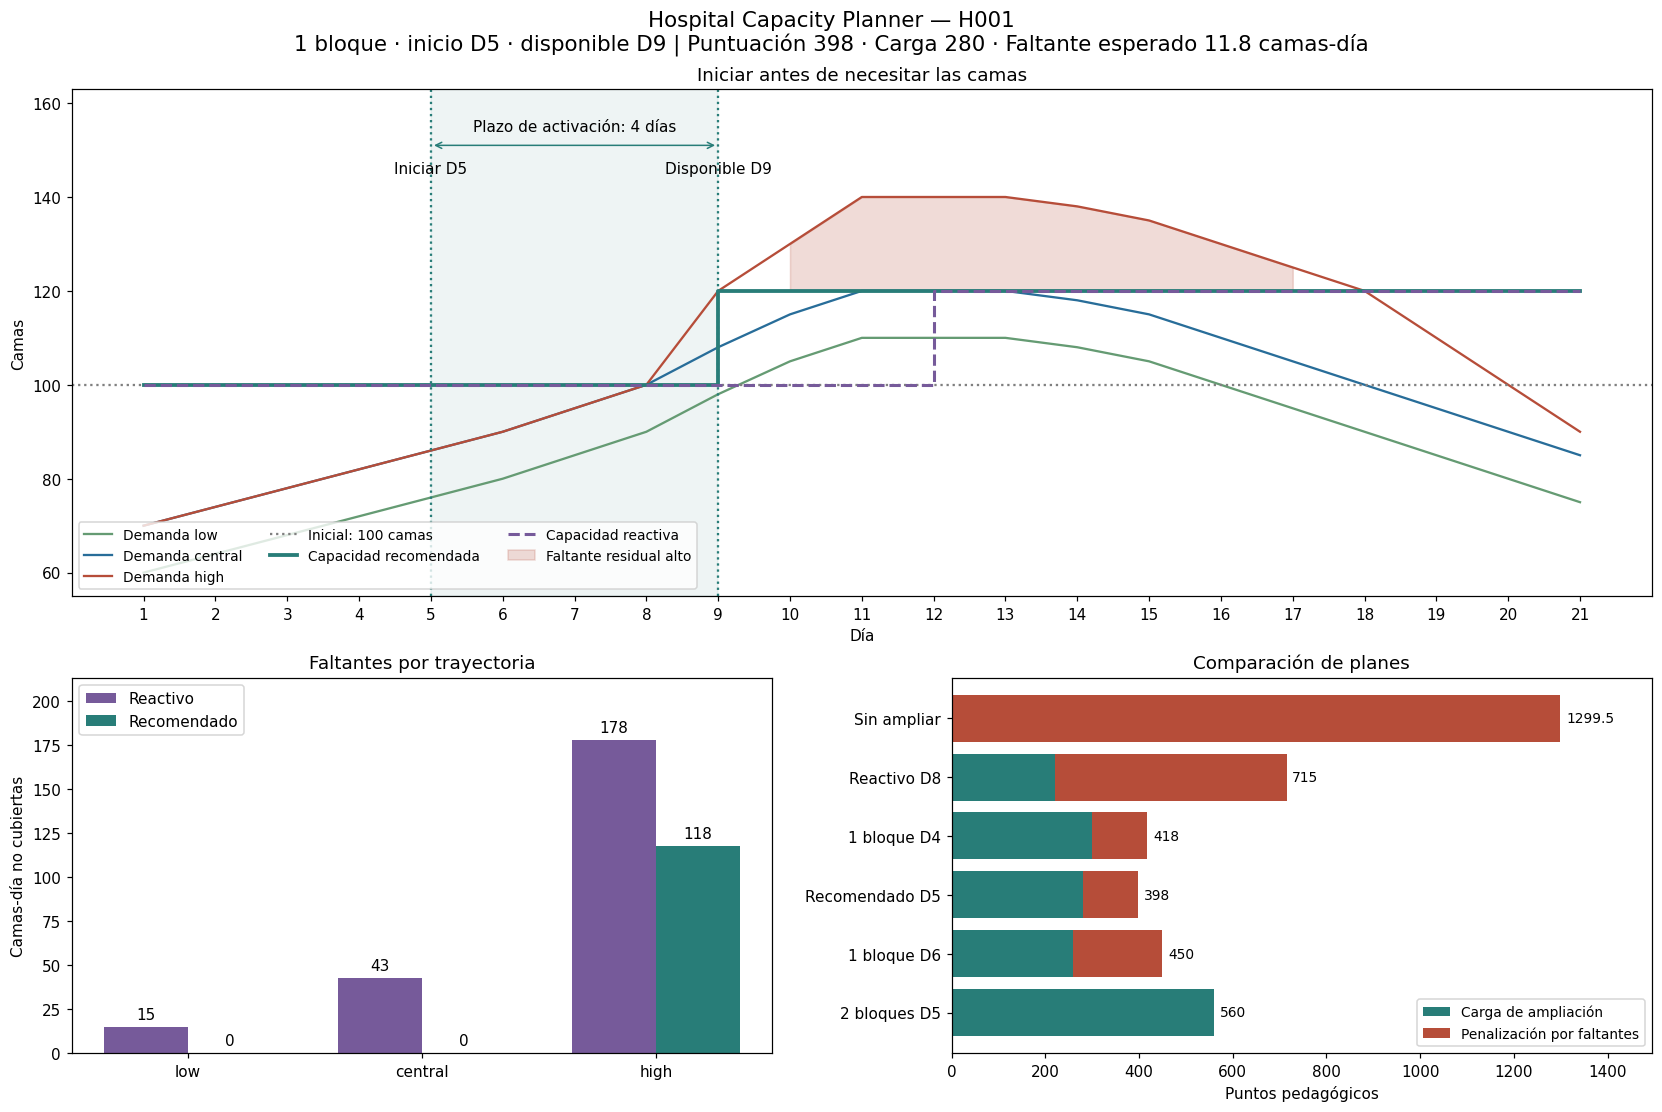

In [28]:
# El plan conserva riesgo residual: 118 camas-día en la trayectoria alta.
x = np.arange(len(scenarios))
reactive_results = plan_scenario_results[plan_scenario_results.plan_id == 'B1_D08'].set_index('scenario_id').loc[scenarios]
for offset, values, label, color in [(-0.18, reactive_results.unmet_bed_days, 'Reactivo', '#765a9a'), (0.18, residual.unmet_bed_days, 'Recomendado', '#287d78')]:
    bars = scenario_ax.bar(x + offset, values, width=0.36, label=label, color=color)
    scenario_ax.bar_label(bars, fmt='%.0f', padding=3)
scenario_ax.set(xticks=x, xticklabels=scenarios, ylabel='Camas-día no cubiertas', title='Faltantes por trayectoria', ylim=(0, reactive_results.unmet_bed_days.max() * 1.2))
scenario_ax.legend(loc='upper left')
comparison_ax.barh(key_labels, key_plans.expansion_burden, color='#287d78', label='Carga de ampliación')
comparison_ax.barh(key_labels, h.shortage_penalty_per_bed_day * key_plans.expected_unmet_bed_days, left=key_plans.expansion_burden, color='#b64d39', label='Penalización por faltantes')
for y, score in enumerate(key_plans.score):
    comparison_ax.text(score + 12, y, f'{score:g}', va='center', fontsize=9)
comparison_ax.invert_yaxis()
comparison_ax.set(xlabel='Puntos pedagógicos', title='Comparación de planes', xlim=(0, key_plans.score.max() * 1.15))
comparison_ax.legend(loc='lower right', fontsize=9)
planner_fig.suptitle(f'Hospital Capacity Planner — {h.hospital_id}\n1 bloque · inicio D{start} · disponible D{available} | Puntuación {best.score:g} · Carga {best.expansion_burden:g} · Faltante esperado {best.expected_unmet_bed_days:g} camas-día', fontsize=14)
display(planner_fig)

In [29]:
# Verificamos resultados base y sensibilidad sin confundir ambas evaluaciones.
assert len(evaluated_plans) == 13 and len(plan_scenario_results) == 39 and len(recommended_daily_plan) == 63
assert not plan_scenario_results.duplicated(['plan_id', 'scenario_id']).any()
assert not recommended_daily_plan.duplicated(['day', 'scenario_id']).any()
assert (reaches_day, exceeds_day, reactive_start, reactive_available, central_reactive_shortage) == (8, 9, 8, 12, 43)
assert best_id == 'B1_D05' and evaluated_plans.is_recommended.sum() == 1
check = evaluated_plans.set_index('plan_id')
assert np.allclose(check.loc[key_ids, 'score'], [1299.5, 715, 418, 398, 450, 560])
assert np.allclose(check.loc[['B1_D08', 'B1_D04', 'B1_D05', 'B2_D05'], 'expected_unmet_bed_days'], [49.5, 11.8, 11.8, 0])
assert np.allclose(check.loc[['B1_D04', 'B1_D05', 'B2_D05'], 'expansion_burden'], [300, 280, 560])
assert residual.unmet_bed_days.tolist() == [0, 0, 118]
assert variant_best_id == 'B2_D05' and np.allclose(variant_scores.loc[['B1_D05', 'B2_D05']], [634, 560])
assert daily.unmet_beds.ge(0).all() and daily.unused_expansion_beds.between(0, daily.available_expansion_beds).all()
assert daily.total_capacity_beds.eq(initial + daily.available_expansion_beds).all()
assert plans.loc[plans.blocks > 0, 'available_day'].eq(plans.loc[plans.blocks > 0, 'activation_day'] + lead).all()
assert np.allclose(evaluated_plans.score, evaluated_plans.expansion_burden + h.shortage_penalty_per_bed_day * evaluated_plans.expected_unmet_bed_days)
assert np.isclose(recommended_daily_plan.groupby('scenario_id').unmet_beds.sum().mul(probabilities.set_index('scenario_id').probability).sum(), best.expected_unmet_bed_days)
print('Verificado: mínimo único B1_D05, puntuación 398; resultados base y sensibilidad correctos.')

Verificado: mínimo único B1_D05, puntuación 398; resultados base y sensibilidad correctos.


In [30]:
# Exportamos únicamente la evaluación y recomendación con probabilidades base.
submission_dir.mkdir(exist_ok=True)
evaluated_plans.to_csv(submission_dir / 'evaluated_plans.csv', index=False)
plan_scenario_results.to_csv(submission_dir / 'plan_scenario_results.csv', index=False)
recommended_daily_plan.to_csv(submission_dir / 'recommended_daily_plan.csv', index=False)
planner_fig.savefig(submission_dir / 'hospital_capacity_planner.png', dpi=180, bbox_inches='tight', facecolor='white')
display([str(submission_dir / name) for name in ['evaluated_plans.csv', 'plan_scenario_results.csv', 'recommended_daily_plan.csv', 'hospital_capacity_planner.png']])

['../submission/evaluated_plans.csv',
 '../submission/plan_scenario_results.csv',
 '../submission/recommended_daily_plan.csv',
 '../submission/hospital_capacity_planner.png']